In [1]:
from typing import Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import ode

from history_matching import latin_hypercube_sampler as lhs
from history_matching import Situation, Recipe, Config, do_step
from history_matching import OBSERVATIONS_COLUMNS, PARAMETER_SPACE_COLUMNS

Loaded tensorflow-probability version 0.21.0.
Loaded tensorflow-probability version 0.21.0.


In [2]:
%matplotlib inline
plt.rcParams['figure.figsize'] = [10, 5]

In [3]:
POPULATION = 1000
DURATION = 90

TARGET_R0 = 2.5
TARGET_GAMMA = 0.2
TARGET_INITIAL = 10.0

T_INF = 14
T_INC = 21
T_SUS = 90

Our model is a simple SIR model:<br>
<div style="text-align:center">
$ dS/dt = -R_{0} \gamma S I / N $<br>
$ dI/dt = R_{0} \gamma S I / N - \gamma I $<br>
$ dR/dt = \gamma I $
</div>

In [4]:
def model(_: float, y: np.array, params: np.array) -> np.array:
    """Model."""

    dydt = np.zeros_like(y)

    r0 = params[0]
    gamma = params[1]
    beta = r0 * gamma
    
    dydt[0] = -y[0] * y[1] * beta / POPULATION  # S, susceptible
    dydt[1] = +y[0] * y[1] * beta / POPULATION - y[1] * gamma  # I, infected
    dydt[2] = +y[1] * gamma  # R, recovered

    return dydt


Manually calculate the Jacobian:<br>
<div style="text-align: center">
$ dS/dS = -R_{0} \gamma I / N $<br>
$ dS/dI = -R_{0} \gamma S / N $<br>
$ dI/dS = R_{0} \gamma I / N $<br>
$ dI/dI = R_{0} \gamma S / N - \gamma $<br>
$ dR/dI = \gamma $<br>
</div>

In [5]:
def jacobian(_: float, y: np.array, params: np.array) -> np.array:
    """Jacobian."""

    r0 = params[0]
    gamma = params[1]
    beta = r0 * gamma
    
    J = np.zeros((3, 3))
    J[0, 0] = -beta * y[1] / POPULATION
    J[0, 1] = -beta * y[0] / POPULATION
    J[1, 0] = +beta * y[1] / POPULATION
    J[1, 1] = +beta * y[0] / POPULATION - gamma
    J[2, 1] = +gamma

    return J

Run one trajectory.

In [6]:
def trajectory(params: np.array) -> Tuple[np.array, np.array, np.array]:
    """Return one trajectory."""

    y0 = np.array([POPULATION - params[2], params[2], 0.0])  # S, I, R
    t0 = 0.0

    r = ode(model, jacobian).set_integrator("dopri5")
    r.set_initial_value(y0, t0).set_f_params(params[0:2]).set_jac_params(params[0:2])

    tmax = float(DURATION)
    dt = 1.0
    sus = np.zeros(int(tmax) + 1)
    sus[0] = y0[0]
    inf = np.zeros(int(tmax) + 1)
    inf[0] = y0[1]
    rec = np.zeros(int(tmax) + 1)
    rec[0] = y0[2]
    while r.successful() and r.t < tmax:
        r.integrate(r.t + dt)
        sus[int(r.t)] = r.y[0]
        inf[int(r.t)] = r.y[1]
        rec[int(r.t)] = r.y[2]

    return sus, inf, rec

In [7]:
def plot_epidemic(susceptible: np.array, infected: np.array, recovered: np.array) -> None:
    plt.figure("Epidemic Scenario")
    plt.plot(susceptible, label="susceptible", color="blue")
    plt.plot(infected, label="infected", color="red")
    plt.plot(recovered, label="recovered", color="green")
    incidence = np.zeros_like(infected)
    incidence[1:] = infected[1:] - infected[:-1]
    plt.plot(incidence, label="incidence", color="purple")
    plt.plot(T_INF, infected[T_INF], "o", color="red")
    plt.plot(T_INC, incidence[T_INC], "o", color="purple")
    plt.plot(T_SUS, susceptible[T_SUS], "o", color="blue")
    plt.legend()
    plt.show()

    return

Run the model once for each set of parameters (row of the `points` DataFrame) and extract the known features:<br>
* number of infected at day 14 (default)
* incidence at day 21 (default)
* "final" susceptible population at day 90 (default)

In [8]:
def run_model(iteration: int, points: pd.DataFrame, config: Config) -> pd.DataFrame:
    """Run model."""

    # features are:
    # infected at day 14 (default)
    # incidence at day 21 (default)
    # susceptible at day 90 (default)

    inf = np.zeros(len(points))
    inc = np.zeros(len(points))
    sus = np.zeros(len(points))

    for index, parameters in enumerate(points.itertuples()):
        params = np.array([parameters.beta, parameters.gamma, parameters.initial])
        susceptible, infected, _ = trajectory(params)  # We don't use recovered.
        inf[index] = infected[config.user.t_inf]
        inc[index] = infected[config.user.t_inc] - infected[config.user.t_inc - 1]
        sus[index] = susceptible[config.user.t_sus]

    results = pd.DataFrame(
        {
            "iteration": iteration,
            "replicate": np.zeros(len(points), np.uint32),
            "beta": points.beta,
            "gamma": points.gamma,
            "initial": points.initial,
            "infected": inf,
            "incidence": inc,
            "susceptible": sus,
        }
    )

    return results

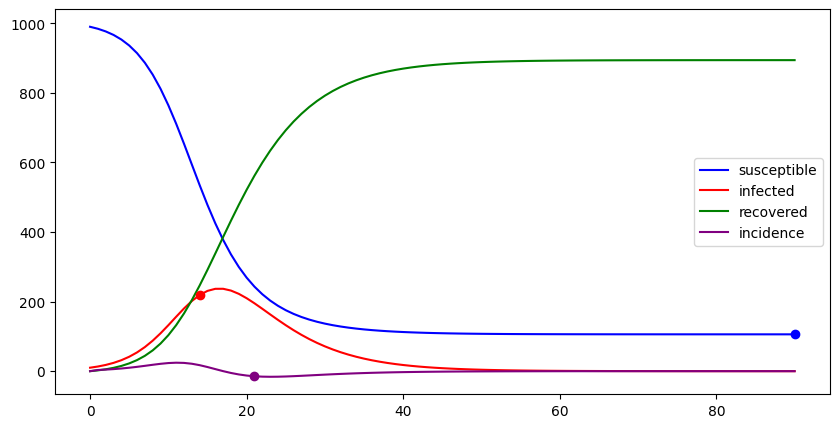

In [9]:
params = np.array([TARGET_R0, TARGET_GAMMA, TARGET_INITIAL])
susceptible, infected, recovered = trajectory(params)
inf14 = infected[T_INF]
inc21 = infected[T_INC] - infected[T_INC - 1]
sus90 = susceptible[T_SUS]

parameter_space = pd.DataFrame([["beta", 0.5, 5.0], ["gamma", 1 / 10, 1 / 2], ["initial", 1, 20]], columns=PARAMETER_SPACE_COLUMNS)
observations = pd.DataFrame([["infected", inf14, 0.0], ["incidence", inc21, 0.0], ["susceptible", sus90, 0.0]], columns=OBSERVATIONS_COLUMNS)
initial_points = lhs(parameter_space, 250)
initial_points["iteration"] = 0
situation = Situation(parameter_space, observations, initial_points)

recipe = Recipe()
recipe.start_step_callback = lambda situation: print(f"Starting step {situation.iteration}")
recipe.run_simulators = run_model
recipe.end_step_callback = lambda situation: print(f"Ending step {situation.iteration}")

config = Config(max_iterations=10, candidates_per_iteration=250, implausibility_threshold=1.5, non_implausible_target=0.01, model_variance=0.0, t_inf=T_INF, t_inc=T_INC, t_sus=T_SUS)

plot_epidemic(susceptible, infected, recovered)

In [10]:
do_step(situation, recipe, config)
print(f"Chose {list(situation.emulator_bank[situation.iteration-1].keys())} for emulation.")

Starting step 0
╒═════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤═════════╕
│ name                    │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │   value │
╞═════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪═════════╡
│ GPR.kernel.variance     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │       1 │
├─────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────┤
│ GPR.kernel.lengthscales │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │       1 │
├─────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────┤
│ GPR.likelihood.variance │ Parameter │ Softplus + Shift │         │ True        │ ()      │ float64 │       1 │
╘═════════════════════════╧═══════════╧══════════════════╧═════════╧════════════

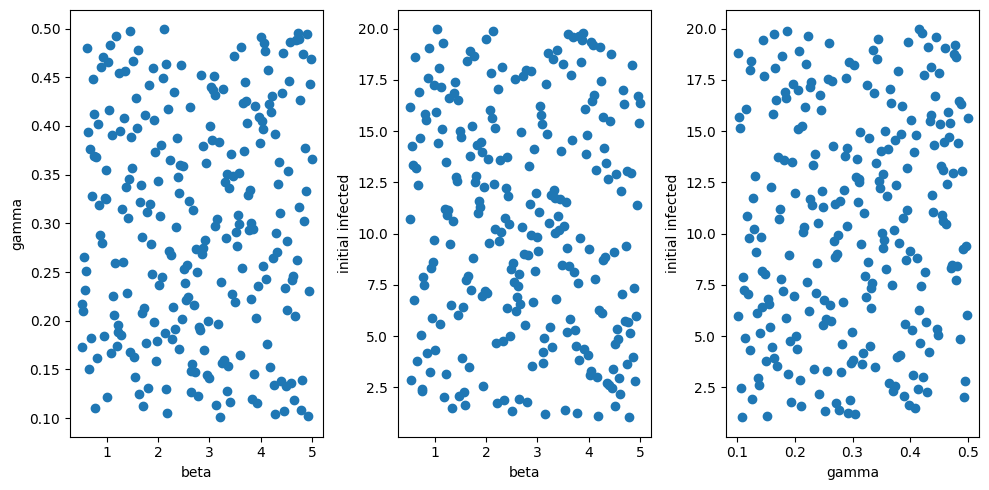

In [11]:
def plot_sample_points(sample_points, iteration):
    sp = sample_points[sample_points.iteration == iteration]
    figure, axes = plt.subplots(1, 3)
    plt.subplot(1,3,1)
    plt.scatter(sp.beta, sp.gamma)
    axes[0].set_xlabel("beta")
    axes[0].set_ylabel("gamma")
    plt.subplot(1,3,2)
    plt.scatter(sp.beta, sp.initial)
    axes[1].set_xlabel("beta")
    axes[1].set_ylabel("initial infected")
    plt.subplot(1,3,3)
    plt.scatter(sp.gamma, sp.initial)
    axes[2].set_xlabel("gamma")
    axes[2].set_ylabel("initial infected")
    plt.tight_layout()
    plt.show()

plot_sample_points(situation.sample_points, 0)

dict_keys(['susceptible'])


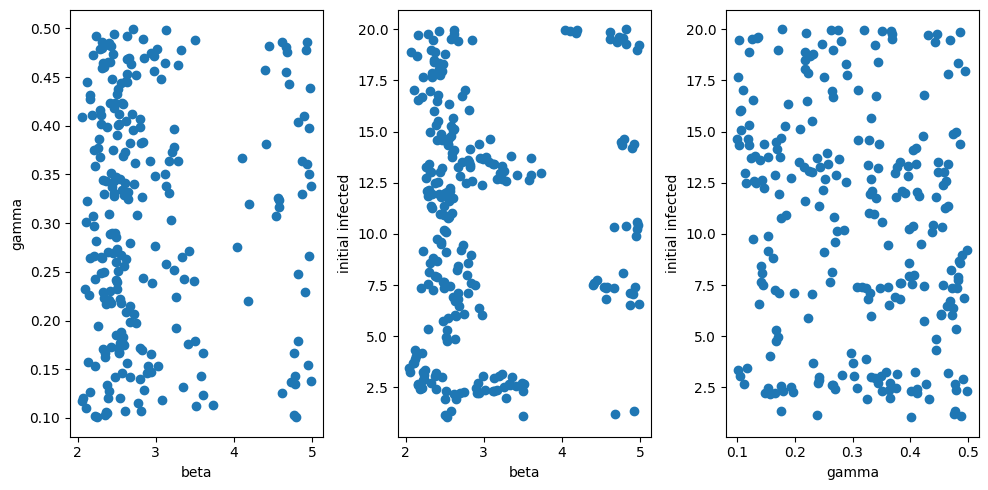

In [12]:
print(situation.emulator_bank[0].keys())
plot_sample_points(situation.sample_points, 1)

In [13]:
do_step(situation, recipe, config)
print(f"Chose {list(situation.emulator_bank[situation.iteration-1].keys())} for emulation.")

Starting step 1
╒═════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤═════════╕
│ name                    │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │   value │
╞═════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪═════════╡
│ GPR.kernel.variance     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │       1 │
├─────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────┤
│ GPR.kernel.lengthscales │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │       1 │
├─────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────┤
│ GPR.likelihood.variance │ Parameter │ Softplus + Shift │         │ True        │ ()      │ float64 │       1 │
╘═════════════════════════╧═══════════╧══════════════════╧═════════╧════════════

In [14]:
def plot_iteration(iteration: int, situation: Situation) -> None:
    print(f"Plotting iteration {iteration}...")

    # title = f"Iteration {iteration} ({list(situation.emulator_bank[iteration-1].keys())[0]})" if iteration > 0 else f"Iteration {iteration}"
    # plt.figure(title)
    figure, axes = plt.subplots(1, 3)

    points = situation.sample_points[situation.sample_points.iteration == iteration]
    for row in points.itertuples():
        s, i, r = trajectory(np.array([row.beta, row.gamma, row.initial]))
        plt.subplot(1, 3, 1)
        plt.plot(s, linewidth=1)
        plt.subplot(1, 3, 2)
        plt.plot(i, linewidth=1)
        c = np.zeros_like(i)
        c[1:] = i[1:] - i[:-1]
        plt.subplot(1, 3, 3)
        plt.plot(c, linewidth=1)

    # Get "actual" trajectory for comparison.
    s, i, r = trajectory(np.array([TARGET_R0, TARGET_GAMMA, TARGET_INITIAL]))
    plt.subplot(1, 3, 1)
    plt.plot(s, color="green", linewidth=2)
    plt.subplot(1, 3, 2)
    plt.plot(i, color="red", linewidth=2)
    c = np.zeros_like(i)
    c[1:] = i[1:] - i[:-1]
    plt.subplot(1, 3, 3)
    plt.plot(c, color="blue", linewidth=2)

    plt.subplot(1, 3, 1)
    plt.plot(T_SUS, s[T_SUS], "o", color="green")
    plt.subplot(1, 3, 2)
    plt.plot(T_INF, i[T_INF], "o", color="red")
    plt.subplot(1, 3, 3)
    plt.plot(T_INC, i[T_INC] - i[T_INC - 1], "o", color="blue")

    axes[1].set_xlabel("timestep")
    axes[0].set_ylabel("susceptible")
    axes[1].set_ylabel("infected")
    axes[2].set_ylabel("incidence")
    
    plt.tight_layout()
    plt.show()

    return

Plotting iteration 0...


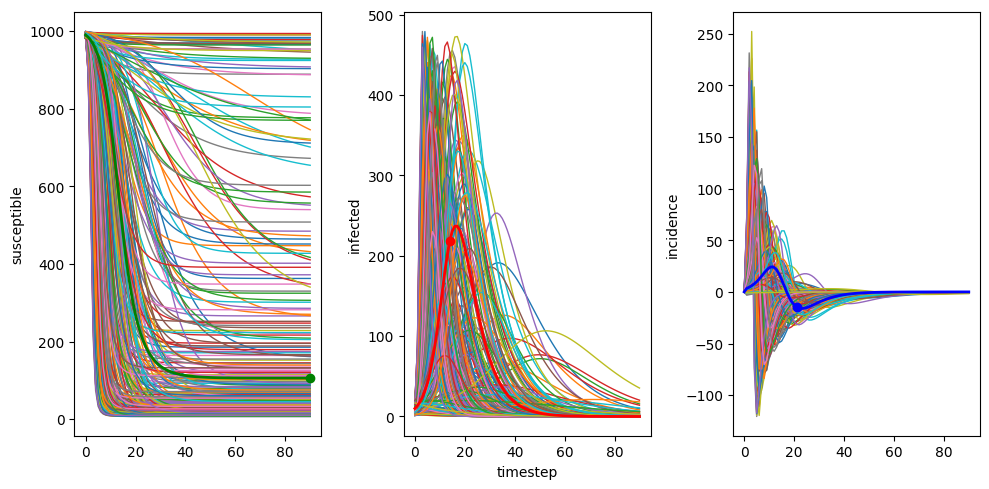

In [15]:
plot_iteration(0, situation)

Plotting iteration 1...


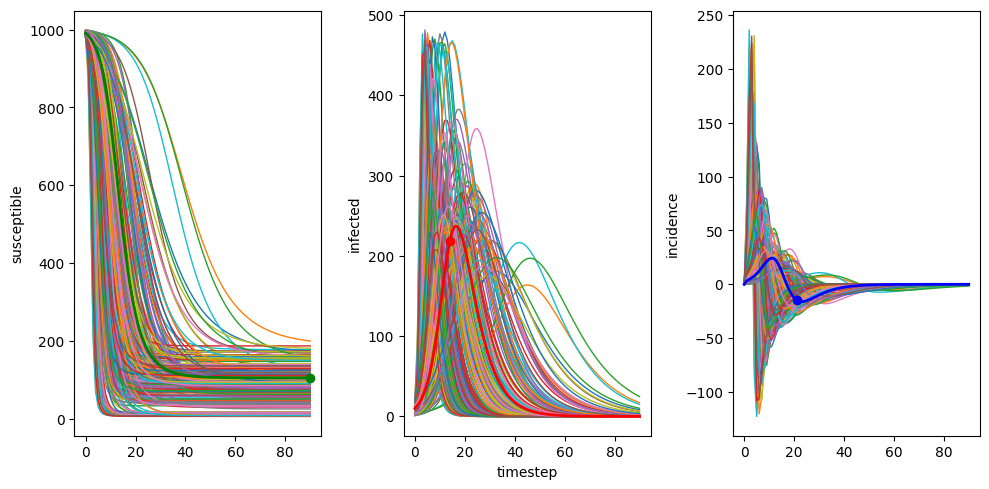

In [16]:
plot_iteration(1, situation)

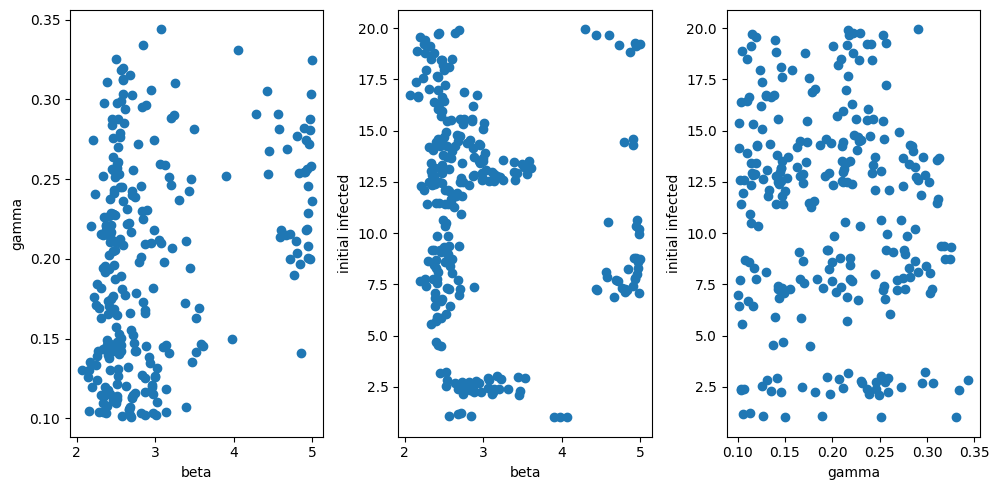

In [17]:
plot_sample_points(situation.sample_points, 2)

In [18]:
do_step(situation, recipe, config)
print(f"Chose {list(situation.emulator_bank[situation.iteration-1].keys())} for emulation.")

Starting step 2
╒═════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤═════════╕
│ name                    │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │   value │
╞═════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪═════════╡
│ GPR.kernel.variance     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │       1 │
├─────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────┤
│ GPR.kernel.lengthscales │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │       1 │
├─────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────┤
│ GPR.likelihood.variance │ Parameter │ Softplus + Shift │         │ True        │ ()      │ float64 │       1 │
╘═════════════════════════╧═══════════╧══════════════════╧═════════╧════════════

Plotting iteration 2...


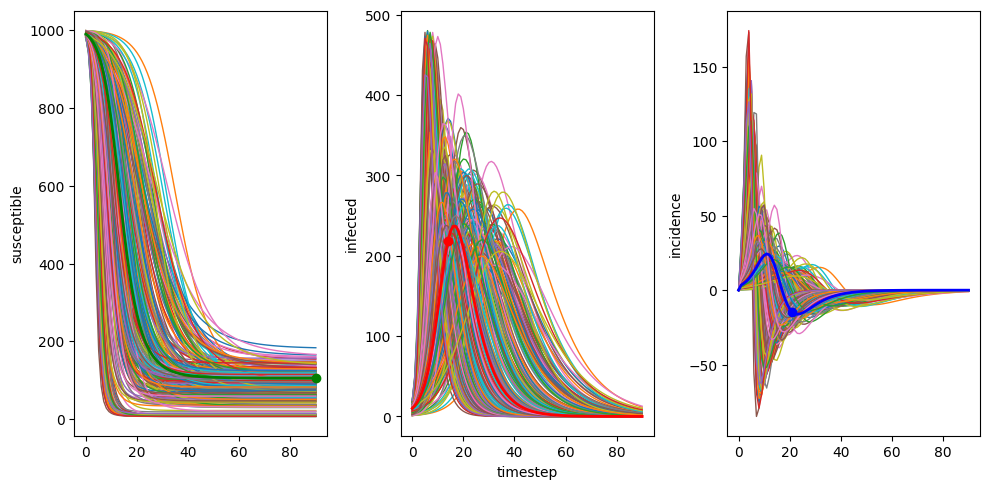

In [19]:
plot_iteration(2, situation)

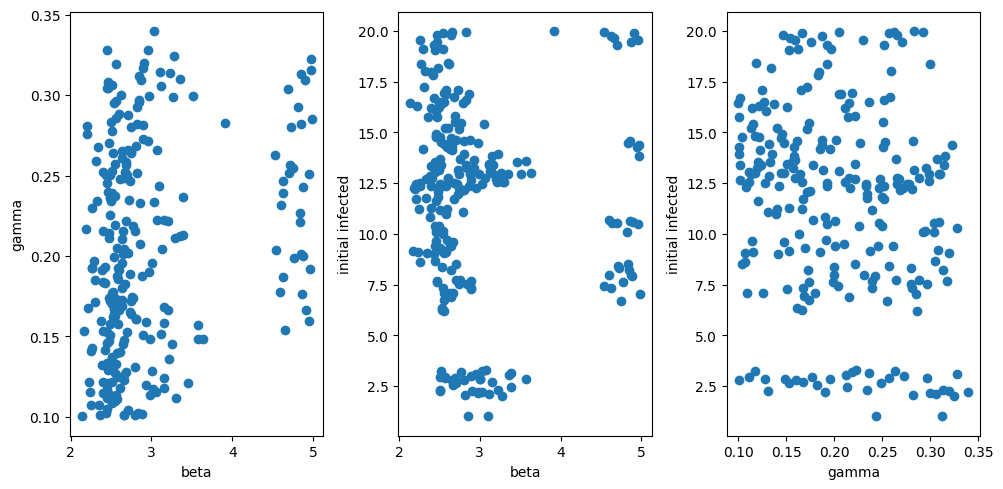

In [20]:
plot_sample_points(situation.sample_points, 3)

In [21]:
do_step(situation, recipe, config)
print(f"Chose {list(situation.emulator_bank[situation.iteration-1].keys())} for emulation.")

Starting step 3
╒═════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤═════════╕
│ name                    │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │   value │
╞═════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪═════════╡
│ GPR.kernel.variance     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │       1 │
├─────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────┤
│ GPR.kernel.lengthscales │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │       1 │
├─────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────┤
│ GPR.likelihood.variance │ Parameter │ Softplus + Shift │         │ True        │ ()      │ float64 │       1 │
╘═════════════════════════╧═══════════╧══════════════════╧═════════╧════════════

Plotting iteration 3...


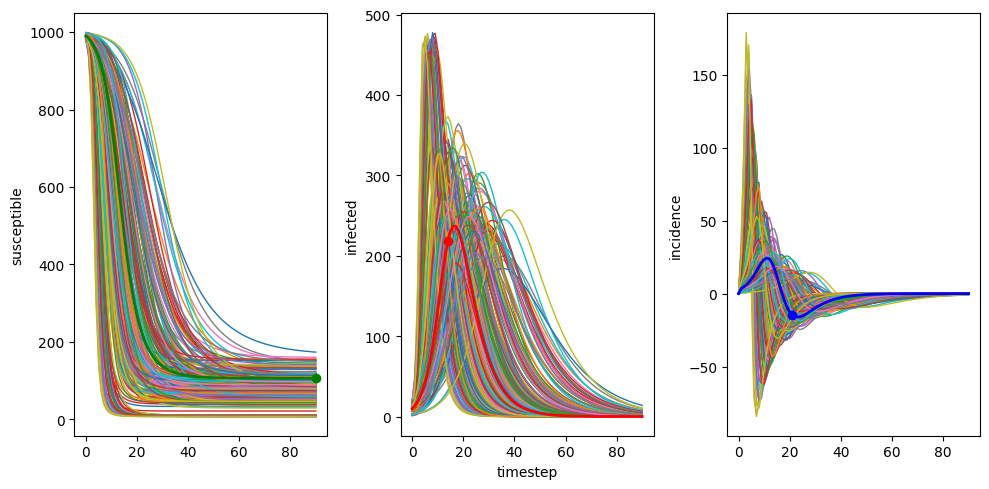

In [22]:
plot_iteration(3, situation)

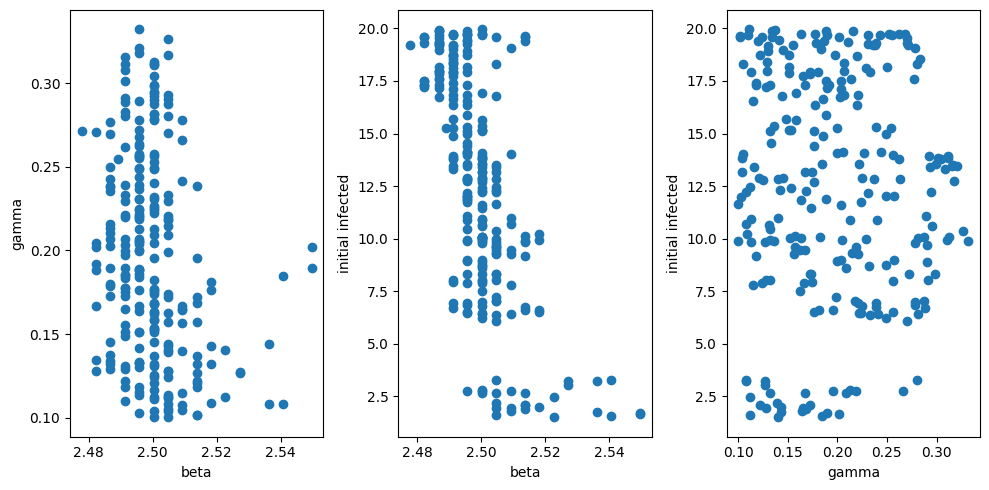

In [23]:
plot_sample_points(situation.sample_points, 4)

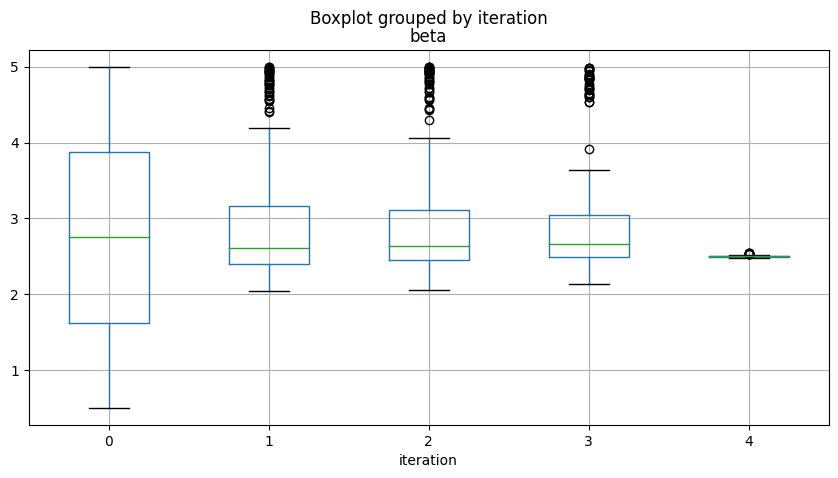

In [24]:
_ = situation.sample_points.boxplot(column="beta", by="iteration")

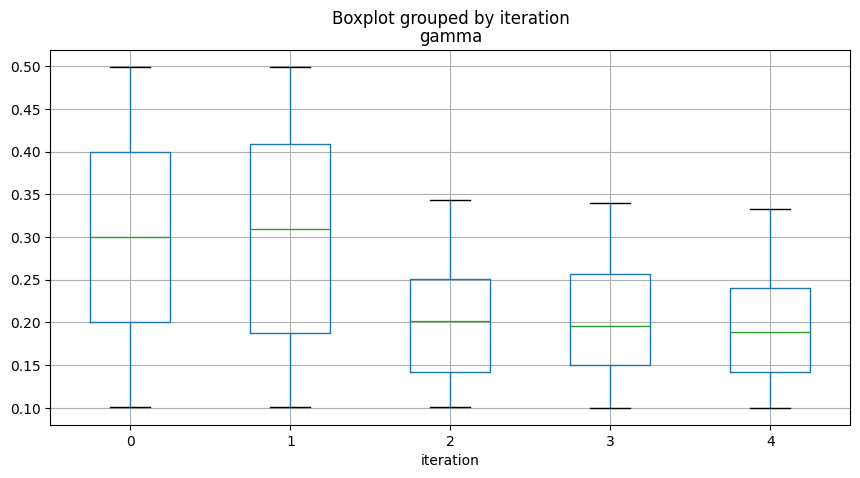

In [25]:
_ = situation.sample_points.boxplot(column="gamma", by="iteration")

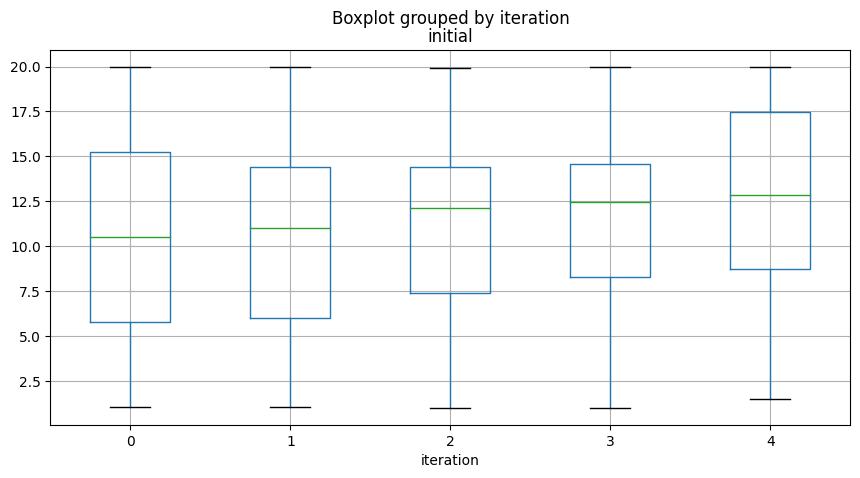

In [26]:
_ = situation.sample_points.boxplot(column="initial", by="iteration")